# DM&Ml Research project
# Data loading , exploring and cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print("All necessary libraries loaded")

All necessary libraries loaded


In [2]:
# columns specified

COLUMNS = [
    'timestamp',         
    'missing_info',      # fields missing due to anonymisation
    'job_id',            # unique job identifier - like primary key
    'task_index',        
    'machine_id',        # machine which done the task
    'event_type',        # event type
    'user',              # username - anonymised
    'scheduling_class',  # 0-3, higher = more latency sensitive
    'priority',          # 0-11, higher = more important
    'cpu_requested',     
    'memory_requested',  
    'disk_requested',    
    'different_machine'  # 1 = must run on different machine
]

EVENT_TYPES = {
    0: 'SUBMIT',
    1: 'SCHEDULE',
    2: 'EVICT',
    3: 'FAIL',
    4: 'FINISH',
    5: 'KILL',
    6: 'LOST',
    7: 'UPDATE_PENDING',
    8: 'UPDATE_RUNNING'
}

print("columns specified")

columns specified


# Data loading and reading

In [3]:
import os

for root, dirs, files in os.walk('/kaggle/input/'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/hharikrishnanmr/datas-1/part-00000-of-00500 (4).csv
/kaggle/input/datasets/hharikrishnanmr/datas-1/part-00007-of-00500.csv
/kaggle/input/datasets/hharikrishnanmr/datas-1/part-00001-of-00500.csv
/kaggle/input/datasets/hharikrishnanmr/datas-1/part-00009-of-00500.csv
/kaggle/input/datasets/hharikrishnanmr/datas-1/part-00002-of-00500.csv
/kaggle/input/datasets/hharikrishnanmr/datas-1/part-00006-of-00500.csv
/kaggle/input/datasets/hharikrishnanmr/datas-1/part-00005-of-00500.csv
/kaggle/input/datasets/hharikrishnanmr/datas-1/part-00003-of-00500.csv
/kaggle/input/datasets/hharikrishnanmr/datas-1/part-00008-of-00500.csv
/kaggle/input/datasets/hharikrishnanmr/datas-1/part-00004-of-00500.csv


# Data Loading

In [4]:

import os

PATH = "/kaggle/input/datasets/hharikrishnanmr/datas-1/"

files = sorted([f for f in os.listdir(PATH) 
                if f.endswith('.csv')])
print(f"Files found: {len(files)}")
for f in files:
    print(f"  {f}")

dfs = []
for file in files:
    filepath = os.path.join(PATH, file)
    temp = pd.read_csv(filepath, 
                       header=None, 
                       names=COLUMNS)
    dfs.append(temp)
    print(f"Loaded {file}: {len(temp):,} rows")

df_raw = pd.concat(dfs, ignore_index=True)

print(f"\nTotal rows loaded : {len(df_raw):,}")
print(f"Total columns     : {df_raw.shape[1]}")
print("Data loading completed")

Files found: 10
  part-00000-of-00500 (4).csv
  part-00001-of-00500.csv
  part-00002-of-00500.csv
  part-00003-of-00500.csv
  part-00004-of-00500.csv
  part-00005-of-00500.csv
  part-00006-of-00500.csv
  part-00007-of-00500.csv
  part-00008-of-00500.csv
  part-00009-of-00500.csv
Loaded part-00000-of-00500 (4).csv: 450,146 rows
Loaded part-00001-of-00500.csv: 77,776 rows
Loaded part-00002-of-00500.csv: 160,642 rows
Loaded part-00003-of-00500.csv: 115,400 rows
Loaded part-00004-of-00500.csv: 115,555 rows
Loaded part-00005-of-00500.csv: 167,471 rows
Loaded part-00006-of-00500.csv: 154,001 rows
Loaded part-00007-of-00500.csv: 188,349 rows
Loaded part-00008-of-00500.csv: 132,651 rows
Loaded part-00009-of-00500.csv: 265,865 rows

Total rows loaded : 1,827,856
Total columns     : 13
Data loading completed


In [5]:
print("=" * 55)
print(" SHAPE")
print("=" * 55)
print(f"Rows    : {df_raw.shape[0]:,}")
print(f"Columns : {df_raw.shape[1]}")

print("\n" + "=" * 55)
print(" DATA TYPES")
print("=" * 55)
print(df_raw.dtypes)

print("\n" + "=" * 55)
print(" FIRST 5 ROWS")
print("=" * 55)
df_raw.head()

 SHAPE
Rows    : 1,827,856
Columns : 13

 DATA TYPES
timestamp              int64
missing_info         float64
job_id                 int64
task_index             int64
machine_id           float64
event_type             int64
user                  object
scheduling_class       int64
priority               int64
cpu_requested        float64
memory_requested     float64
disk_requested       float64
different_machine    float64
dtype: object

 FIRST 5 ROWS


,timestamp,missing_info,job_id,task_index,machine_id,event_type,user,scheduling_class,priority,cpu_requested,memory_requested,disk_requested,different_machine
0,0,2.0000,3418309,0,4155527081.0000,0,70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,3,9,NaN,NaN,NaN,NaN
1,0,2.0000,3418309,1,329150663.0000,0,70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,3,9,NaN,NaN,NaN,NaN
2,0,NaN,3418314,0,3938719206.0000,0,70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,3,9,0.1250,0.0745,0.0004,0.0000
3,0,NaN,3418314,1,351618647.0000,0,70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,3,9,0.1250,0.0745,0.0004,0.0000
4,0,2.0000,3418319,0,431052910.0000,0,70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,3,9,NaN,NaN,NaN,NaN


# Missing values identification

In [6]:
print("=" * 55)
print(" MISSING VALUES PER COLUMN")
print("=" * 55)

missing_count = df_raw.isnull().sum()
missing_pct   = (missing_count / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing %'     : missing_pct
})
print(missing_df)

print("\n" + "=" * 55)
print(" MISSING RESOURCES BY EVENT TYPE")
print("=" * 55)

resource_null = df_raw.groupby('event_type')['cpu_requested'].apply(
    lambda x: x.isnull().sum()
).reset_index()
resource_null.columns = ['event_type', 'cpu_null_count']
resource_null['event_label'] = resource_null['event_type'].map(EVENT_TYPES)
print(resource_null[['event_label', 'cpu_null_count']])

print("\n" + "=" * 55)
print(" EVENT TYPE DISTRIBUTION")
print("=" * 55)
event_dist = df_raw['event_type'].map(EVENT_TYPES).value_counts()
print(event_dist)
print(f"\nTotal events : {len(df_raw):,}")

 MISSING VALUES PER COLUMN
                   Missing Count  Missing %
timestamp                      0     0.0000
missing_info             1827565    99.9800
job_id                         0     0.0000
task_index                     0     0.0000
machine_id                636045    34.8000
event_type                     0     0.0000
user                           0     0.0000
scheduling_class               0     0.0000
priority                       0     0.0000
cpu_requested                291     0.0200
memory_requested             291     0.0200
disk_requested               291     0.0200
different_machine            291     0.0200

 MISSING RESOURCES BY EVENT TYPE
      event_label  cpu_null_count
0          SUBMIT             291
1        SCHEDULE               0
2           EVICT               0
3            FAIL               0
4          FINISH               0
5            KILL               0
6  UPDATE_PENDING               0
7  UPDATE_RUNNING               0

 EVENT TYPE DIST

# Visualizations

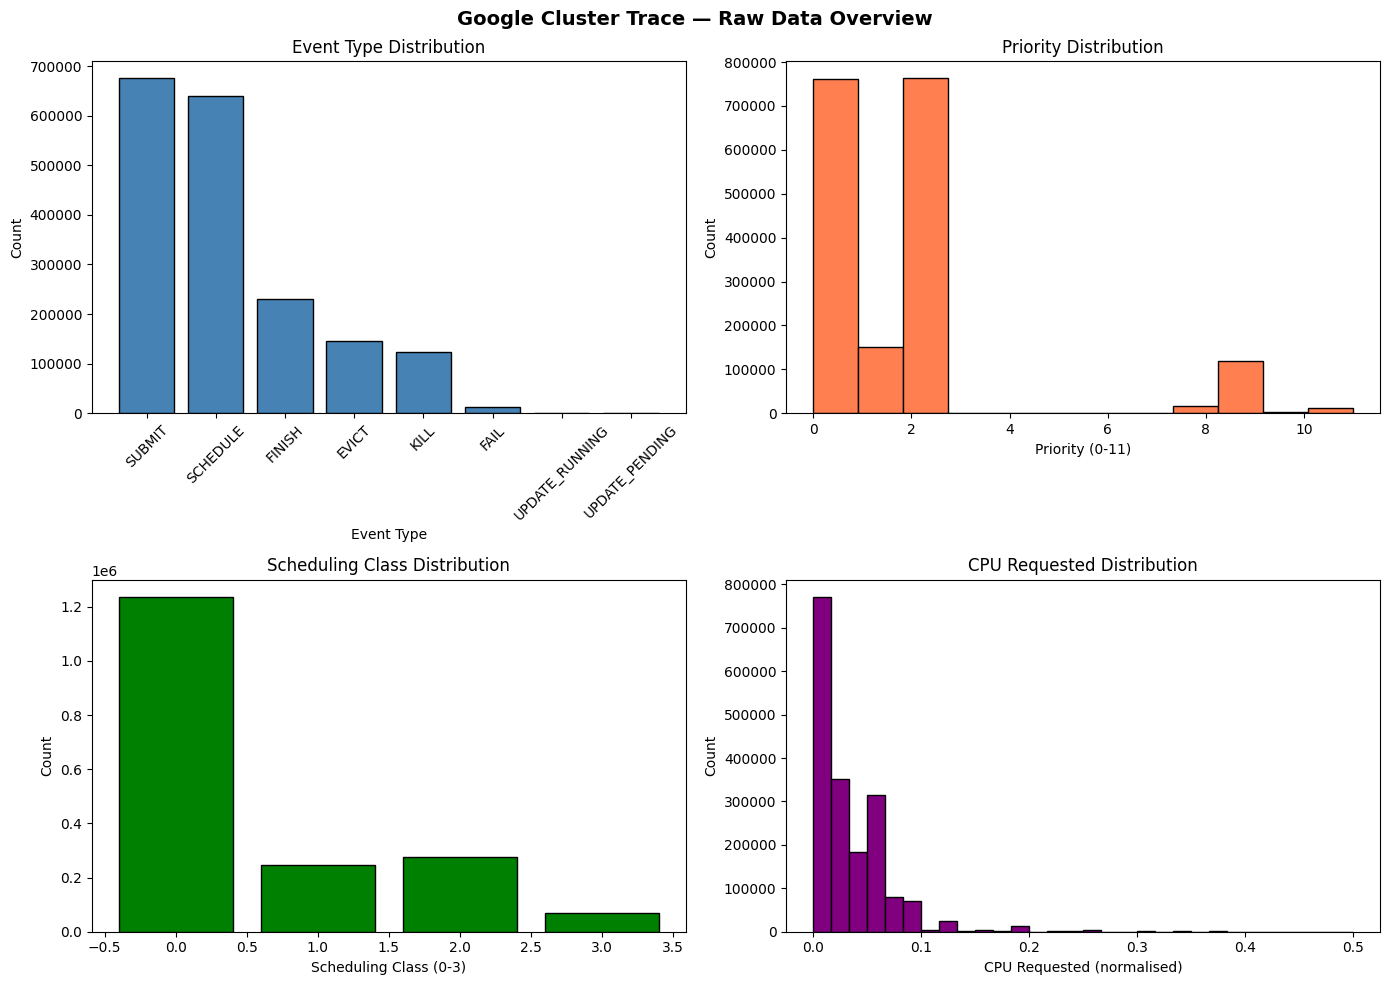

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Google Cluster Trace — Raw Data Overview', 
             fontsize=14, fontweight='bold')

event_counts = df_raw['event_type'].map(EVENT_TYPES).value_counts()
axes[0,0].bar(event_counts.index, event_counts.values, color='steelblue', edgecolor='black')
axes[0,0].set_title('Event Type Distribution')
axes[0,0].set_xlabel('Event Type')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=45)

axes[0,1].hist(df_raw['priority'], bins=12, color='coral', edgecolor='black')
axes[0,1].set_title('Priority Distribution')
axes[0,1].set_xlabel('Priority (0-11)')
axes[0,1].set_ylabel('Count')

sched_counts = df_raw['scheduling_class'].value_counts().sort_index()
axes[1,0].bar(sched_counts.index, sched_counts.values, color='green', edgecolor='black')
axes[1,0].set_title('Scheduling Class Distribution')
axes[1,0].set_xlabel('Scheduling Class (0-3)')
axes[1,0].set_ylabel('Count')

cpu_vals = df_raw['cpu_requested'].dropna()
axes[1,1].hist(cpu_vals, bins=30, color='purple', edgecolor='black')
axes[1,1].set_title('CPU Requested Distribution')
axes[1,1].set_xlabel('CPU Requested (normalised)')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('raw_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Data cleaning

In [8]:

df = df_raw.copy()
print(f"Starting shape: {df.shape}")

df = df.drop(columns=['missing_info'])
print(f"\n Dropped missing_info column since majority is null")
print(f"  Shape now: {df.shape}")

before = len(df)
df = df.drop_duplicates()
print(f"\n Duplicates removed: {before - len(df):,}")
print(f"    Shape now: {df.shape}")

before = len(df)
df = df.dropna(subset=['job_id', 'task_index'])
print(f"\n Rows dropped - missing job/task ID): {before - len(df):,}")
print(f"    Shape now: {df.shape}")

df['machine_id'] = df['machine_id'].fillna(-1).astype('int64')
print(f"\n machine_id nulls filled with -1 (pre-schedule placeholder)")

resource_cols = ['cpu_requested', 'memory_requested', 
                 'disk_requested', 'different_machine']

df = df.sort_values(['job_id', 'task_index', 'timestamp'])

for col in resource_cols:
    df[col] = (df.groupby(['job_id', 'task_index'])[col]
                 .ffill()
                 .fillna(0))

print(f"\n Resource columns forward-filled within task lifecycle")
print(f"    Remaining nulls in resource cols:")
print(f"    {df[resource_cols].isnull().sum().to_dict()}")

df['different_machine'] = df['different_machine'].astype(int)

df['event_label'] = df['event_type'].map(EVENT_TYPES)

print(f"\n FINAL CLEAN SHAPE: {df.shape}")
print(f"\nRemaining nulls:")
print(df.isnull().sum())

Starting shape: (1827856, 13)

 Dropped missing_info column since majority is null
  Shape now: (1827856, 12)

 Duplicates removed: 0
    Shape now: (1827856, 12)

 Rows dropped - missing job/task ID): 0
    Shape now: (1827856, 12)

 machine_id nulls filled with -1 (pre-schedule placeholder)

 Resource columns forward-filled within task lifecycle
    Remaining nulls in resource cols:
    {'cpu_requested': 0, 'memory_requested': 0, 'disk_requested': 0, 'different_machine': 0}

 FINAL CLEAN SHAPE: (1827856, 13)

Remaining nulls:
timestamp            0
job_id               0
task_index           0
machine_id           0
event_type           0
user                 0
scheduling_class     0
priority             0
cpu_requested        0
memory_requested     0
disk_requested       0
different_machine    0
event_label          0
dtype: int64


# Label creation - Dependent variable
label = 1 Deadlock Condition , 
label = 0 normal completion

 FINAL EVENTS EXTRACTED
Unique tasks : 464,004

Final event distribution:
event_label
FINISH            228546
SCHEDULE          122948
KILL               71351
SUBMIT             40369
FAIL                 739
UPDATE_RUNNING        43
EVICT                  8
Name: count, dtype: int64

  After keeping terminal events only:
Tasks remaining : 300,644

 LABEL DISTRIBUTION (DEPENDENT VARIABLE)
Label 0 - Normal / FINISH         : 228,546 (76.0%)
Label 1 - Deadlock-like / Fail-Kill-Evict : 72,098 (24.0%)

 Class imbalance ratio : 3.17:1


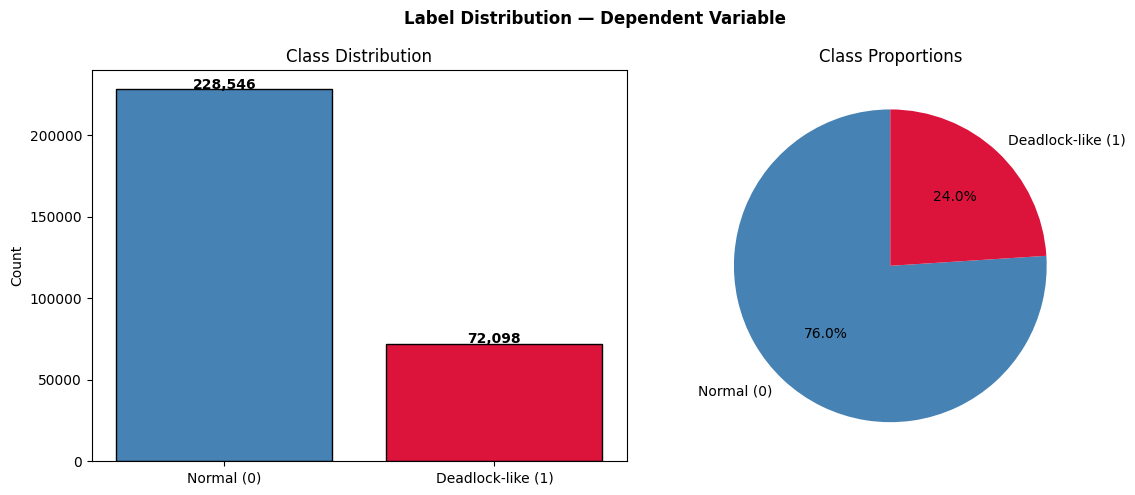

In [9]:
df_sorted = df.sort_values('timestamp')

final_events = (df_sorted
                .groupby(['job_id', 'task_index'])
                .last()
                .reset_index())

print("=" * 55)
print(" FINAL EVENTS EXTRACTED")
print("=" * 55)
print(f"Unique tasks : {len(final_events):,}")
print(f"\nFinal event distribution:")
print(final_events['event_label'].value_counts())

# Removing tasks whose last recorded event is not a terminal state
terminal = ['FINISH', 'FAIL', 'KILL', 'EVICT']
final_events = final_events[final_events['event_label'].isin(terminal)]

print(f"\n  After keeping terminal events only:")
print(f"Tasks remaining : {len(final_events):,}")

# label = 1 : deadlock-like condition -  FAIL, KILL, EVICT
# label = 0 : normal completion - FINISH
final_events['label'] = final_events['event_label'].apply(
    lambda x: 1 if x in ['FAIL', 'KILL', 'EVICT'] else 0
)

print("\n" + "=" * 55)
print(" LABEL DISTRIBUTION (DEPENDENT VARIABLE)")
print("=" * 55)
label_counts = final_events['label'].value_counts()
label_pct    = final_events['label'].value_counts(normalize=True) * 100

print(f"Label 0 - Normal / FINISH         : {label_counts[0]:,} ({label_pct[0]:.1f}%)")
print(f"Label 1 - Deadlock-like / Fail-Kill-Evict : {label_counts[1]:,} ({label_pct[1]:.1f}%)")
print(f"\n Class imbalance ratio : {label_counts[0]/label_counts[1]:.2f}:1")

# Visualizing label distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Label Distribution — Dependent Variable', fontweight='bold')

# Bar chart
axes[0].bar(['Normal (0)', 'Deadlock-like (1)'], 
            label_counts.values,
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values,
            labels=['Normal (0)', 'Deadlock-like (1)'],
            colors=['steelblue', 'crimson'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Saving cleaned dataset and labelled one

In [10]:
SAVE_PATH = "/kaggle/working/"

df.to_csv(SAVE_PATH + 'google_trace_clean.csv', index=False)
print(f"Saved: google_trace_clean.csv")
print(f"Shape: {df.shape}")

# Saving labelled task-level dataset
final_events.to_csv(SAVE_PATH + 'google_trace_labelled.csv', index=False)
print(f"\nSaved: google_trace_labelled.csv")
print(f"Shape: {final_events.shape}")

print("\n" + "=" * 55)
print(" SUMMARY")
print("=" * 55)
print(f"Raw rows loaded          : {len(df_raw):,}")
print(f"Clean rows               : {len(df):,}")
print(f"Unique tasks identified  : {df.groupby(['job_id','task_index']).ngroups:,}")
print(f"Terminal tasks (labelled): {len(final_events):,}")
print(f"  Label 0 (Normal)       : {(final_events['label']==0).sum():,} ({(final_events['label']==0).mean()*100:.1f}%)")
print(f"  Label 1 (Deadlock-like): {(final_events['label']==1).sum():,} ({(final_events['label']==1).mean()*100:.1f}%)")
print(f"Class imbalance ratio    : {(final_events['label']==0).sum()/(final_events['label']==1).sum():.2f}:1")
print(f"\nParts loaded    : 10 of 500")
print(f"Columns dropped : missing_info")
print(f"Columns added   : event_label, label")
print(f"Nulls remaining : 0")


Saved: google_trace_clean.csv
Shape: (1827856, 13)

Saved: google_trace_labelled.csv
Shape: (300644, 14)

 SUMMARY
Raw rows loaded          : 1,827,856
Clean rows               : 1,827,856
Unique tasks identified  : 464,004
Terminal tasks (labelled): 300,644
  Label 0 (Normal)       : 228,546 (76.0%)
  Label 1 (Deadlock-like): 72,098 (24.0%)
Class imbalance ratio    : 3.17:1

Parts loaded    : 10 of 500
Columns dropped : missing_info
Columns added   : event_label, label
Nulls remaining : 0
